# Post mofa-flex analysis

### Contents:

1. [Load models (Normal, SnS, and GP).](#load-models)

2. [MOFA-Flex model result overview.](#mofa-flex-results-overview)
<br>
2.1 [Factor correlation and variance explained.](#1-variance-explained)
<br>
2.2 [Average R2.](#2-average-r2)
<br>
2.3 [Weights distribution.](#3weights-dist)
<br>
2.4 [Heatmap (view x LR).](#4-heatmap-view-x-lr)

3. [DR and clustering.](#dr-using-factors-values)

4. [Regression Model.](#regression-model)
<br>
4.1 [Evaluate model.](#evaluate-the-model)
<br>
4.2 [AUC.](#auc)

5. [Map clusters to spatial.](#map-clusters-to-spatial)

In [1]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Run MOFA

## Read mdata

In [2]:
mdata_path = Path("/g/stegle/aalsayah/repos/data/slidatag/slidetags/mudata")

In [6]:
mdata = md.read(mdata_path / "SCP2170.h5mu")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


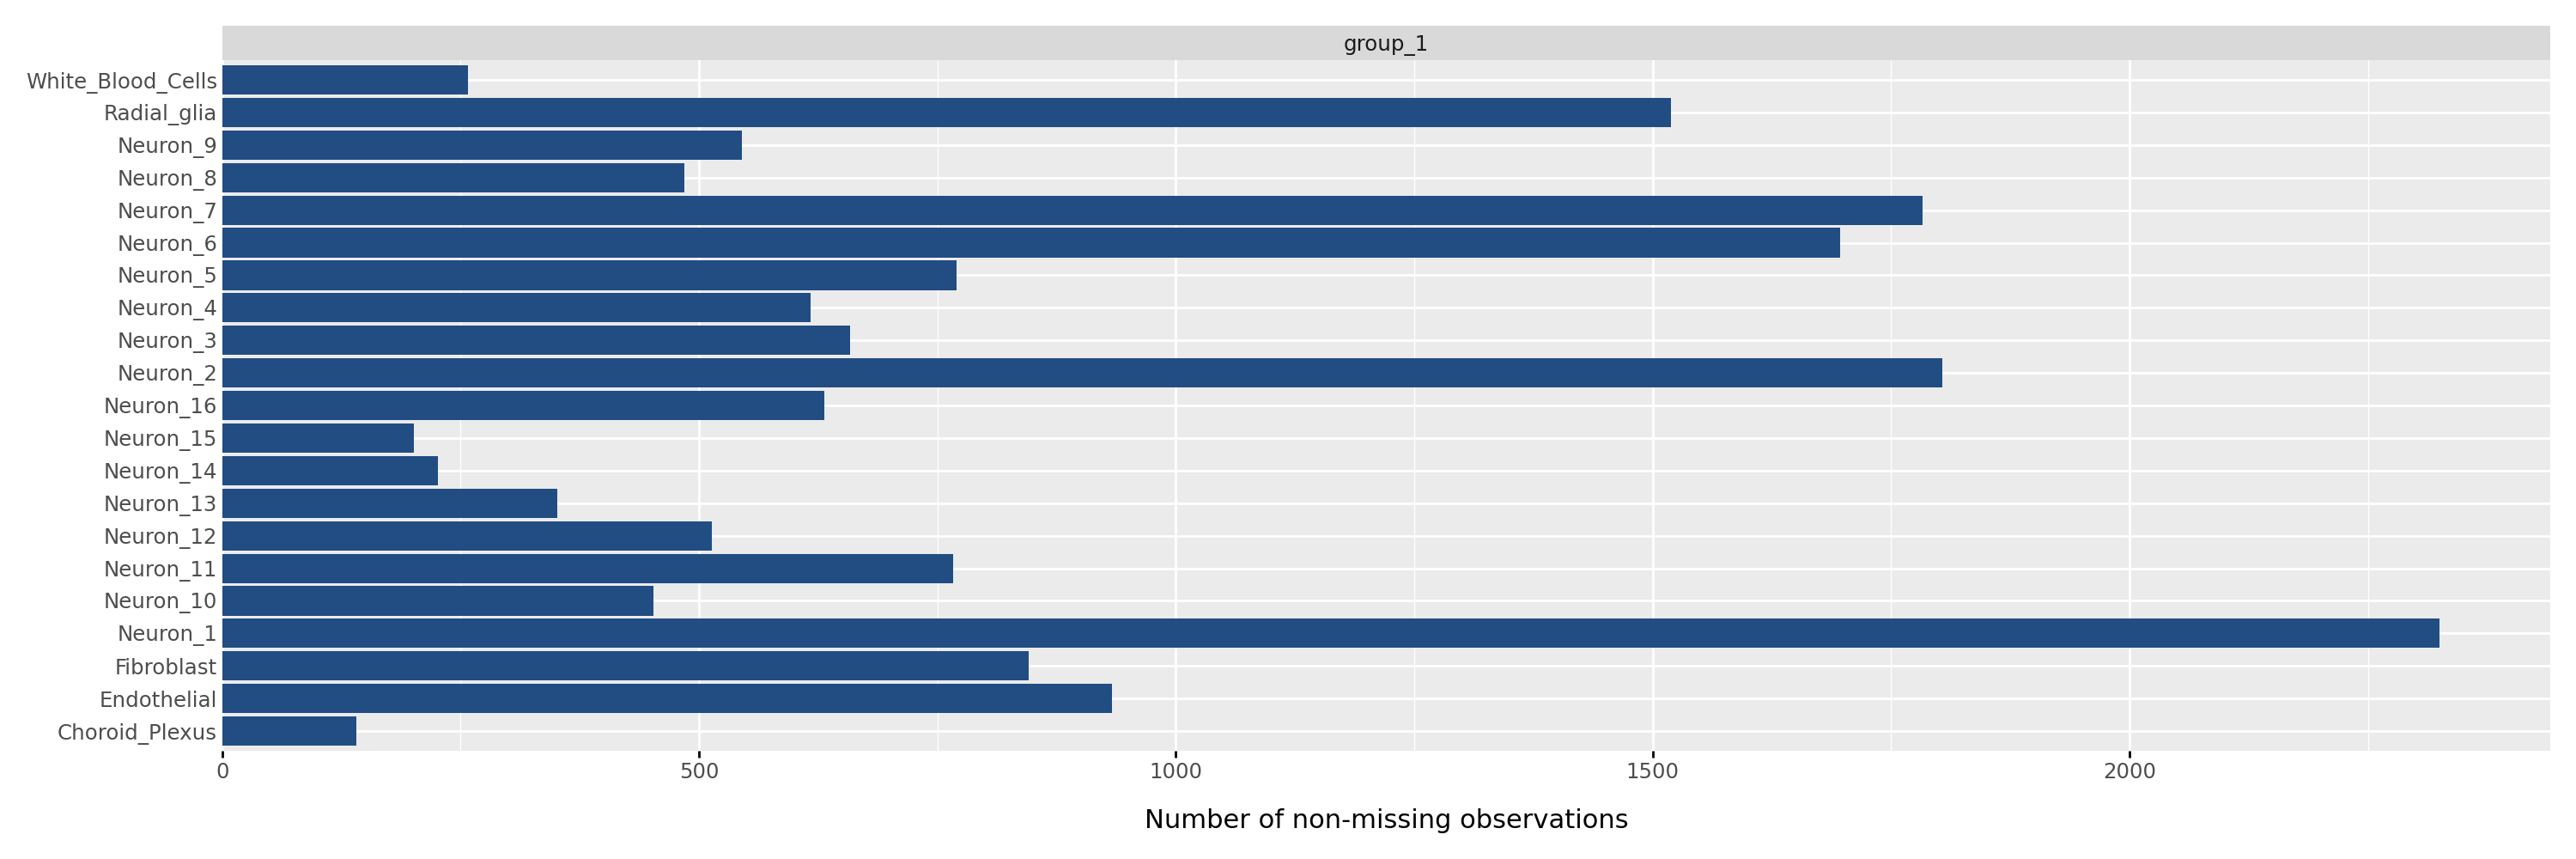

WARNING	Sparse arrays are currently not supported by Dask. Dask will not be used and data arrays may be copied, resulting in high memory usage.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site

  0%|                                                                                                 | 0/1000…

INFO	Training converged after 774 epochs.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
INFO	Saving results to /g/stegle/aalsayah/repos/data/slidatag/slidetags/models/SCP2170_normal_model.hdf5...


In [8]:
model = mfl.MOFAFLEX(
    mdata,
    mfl.ModelOptions(
        n_factors=15,
        factor_prior="Normal",
        likelihoods="Normal",
        weight_prior="Normal",
    ),
    mfl.TrainingOptions(
        batch_size=2000,
        n_particles=10,
        lr=0.005,
        max_epochs=1000,
        save_path=str("/g/stegle/aalsayah/repos/data/slidatag/slidetags/models/SCP2170_normal_model.hdf5"),
        early_stopper_patience=50,
    ),
)

# Load models

### Normal

In [9]:
models_path = Path("/g/stegle/aalsayah/repos/data/slidatag/slidetags/models")

In [10]:
model= mfl.MOFAFLEX.load(models_path / 'SCP2170_normal_model.hdf5')

### SnS

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "sns_models/crc_110/Normal.SnS/crc_110.Normal.SnS.hdf5")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### GP

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "GP_models/crc_232_no_mye_IgM/GP.Normal/crc_232_no_mye_IgM.GP.Normal.hdf5")

# MOFA-Flex results overview

## 1. Variance Explained

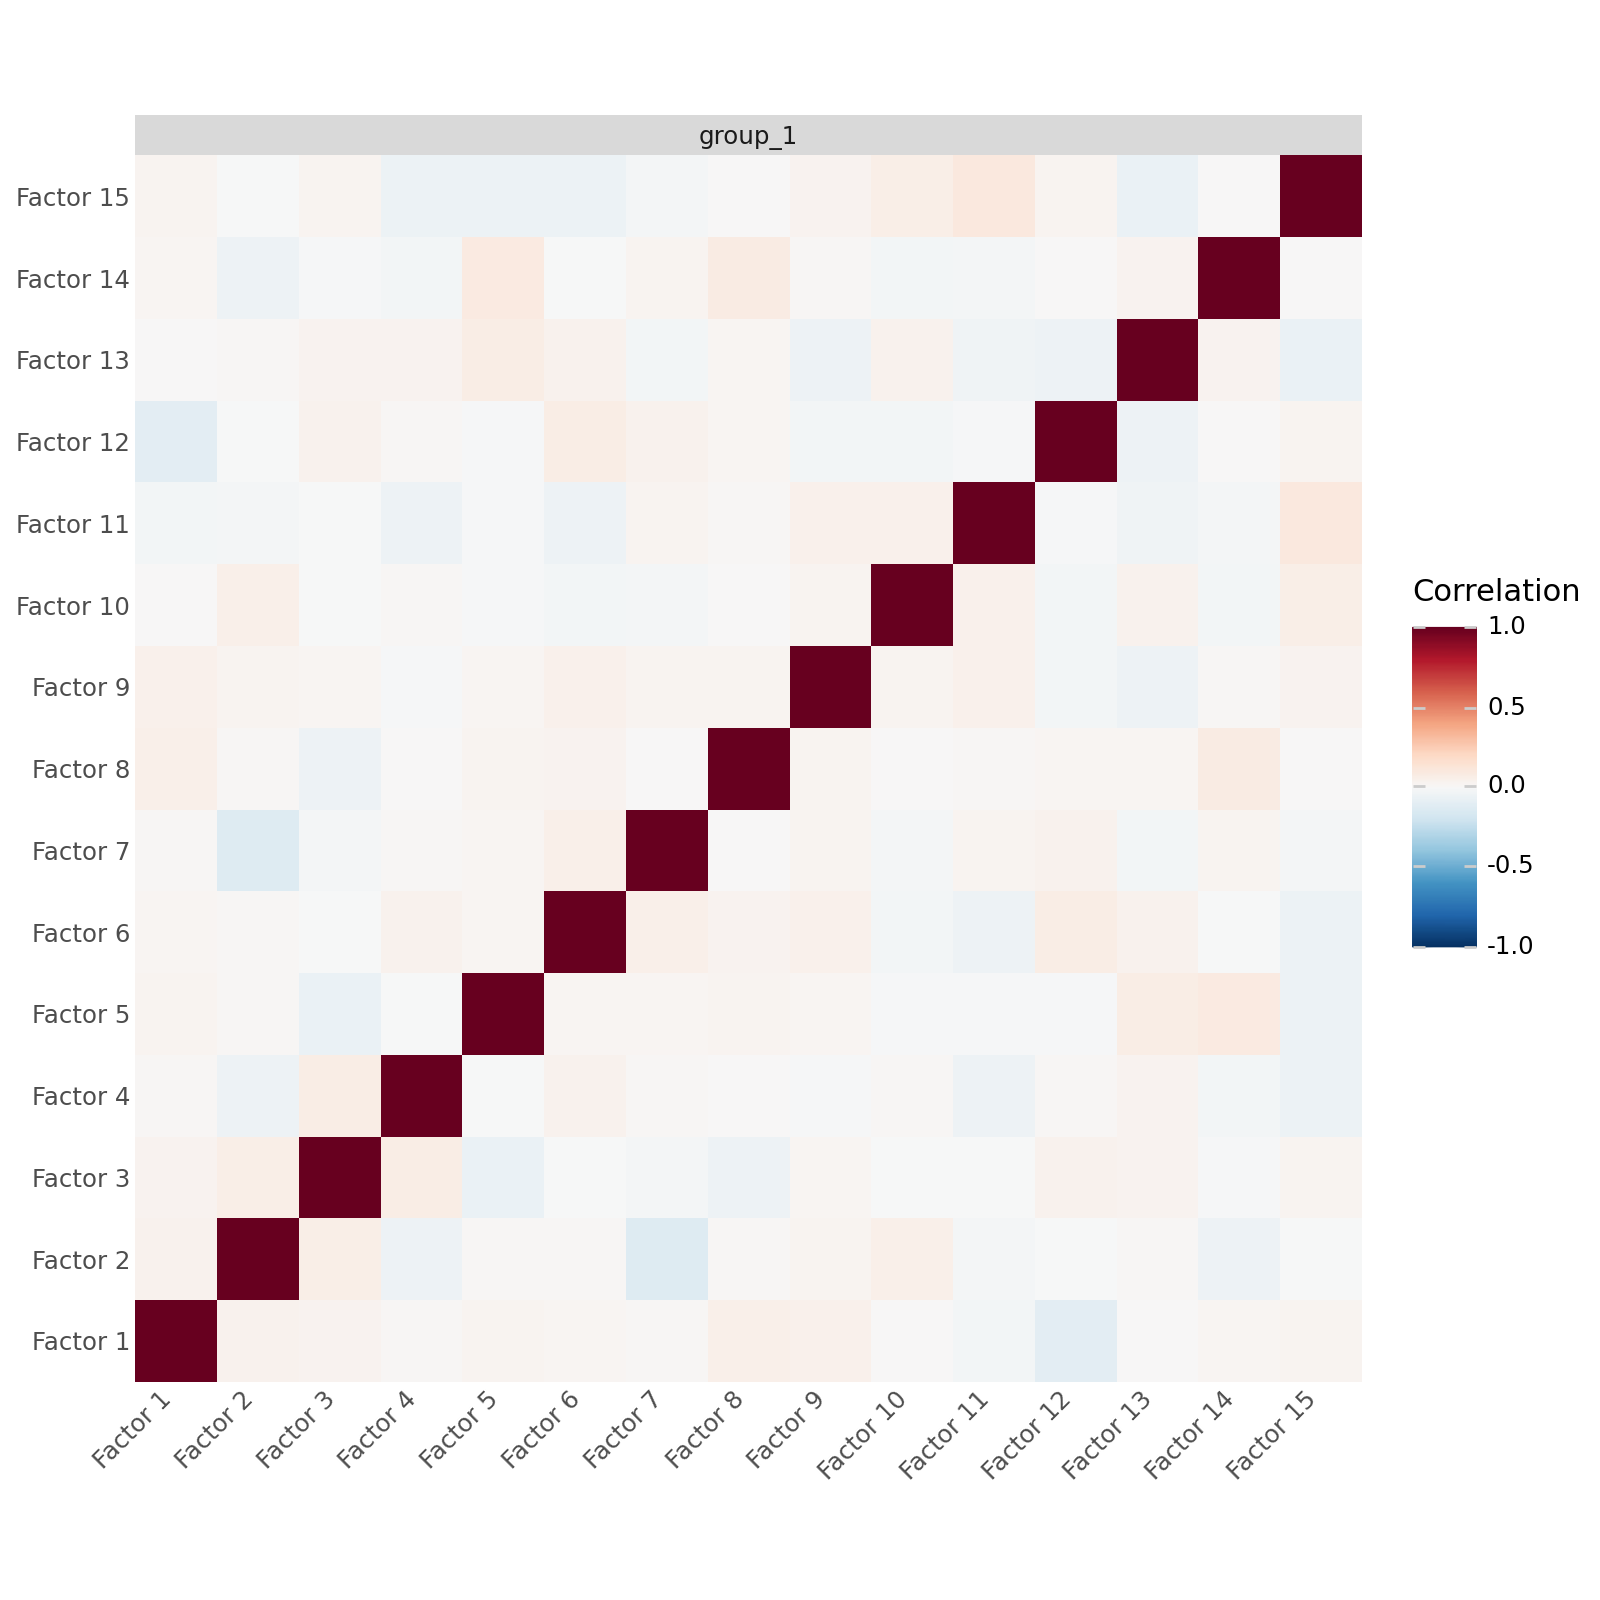

In [11]:
mfl.pl.factor_correlation(model)

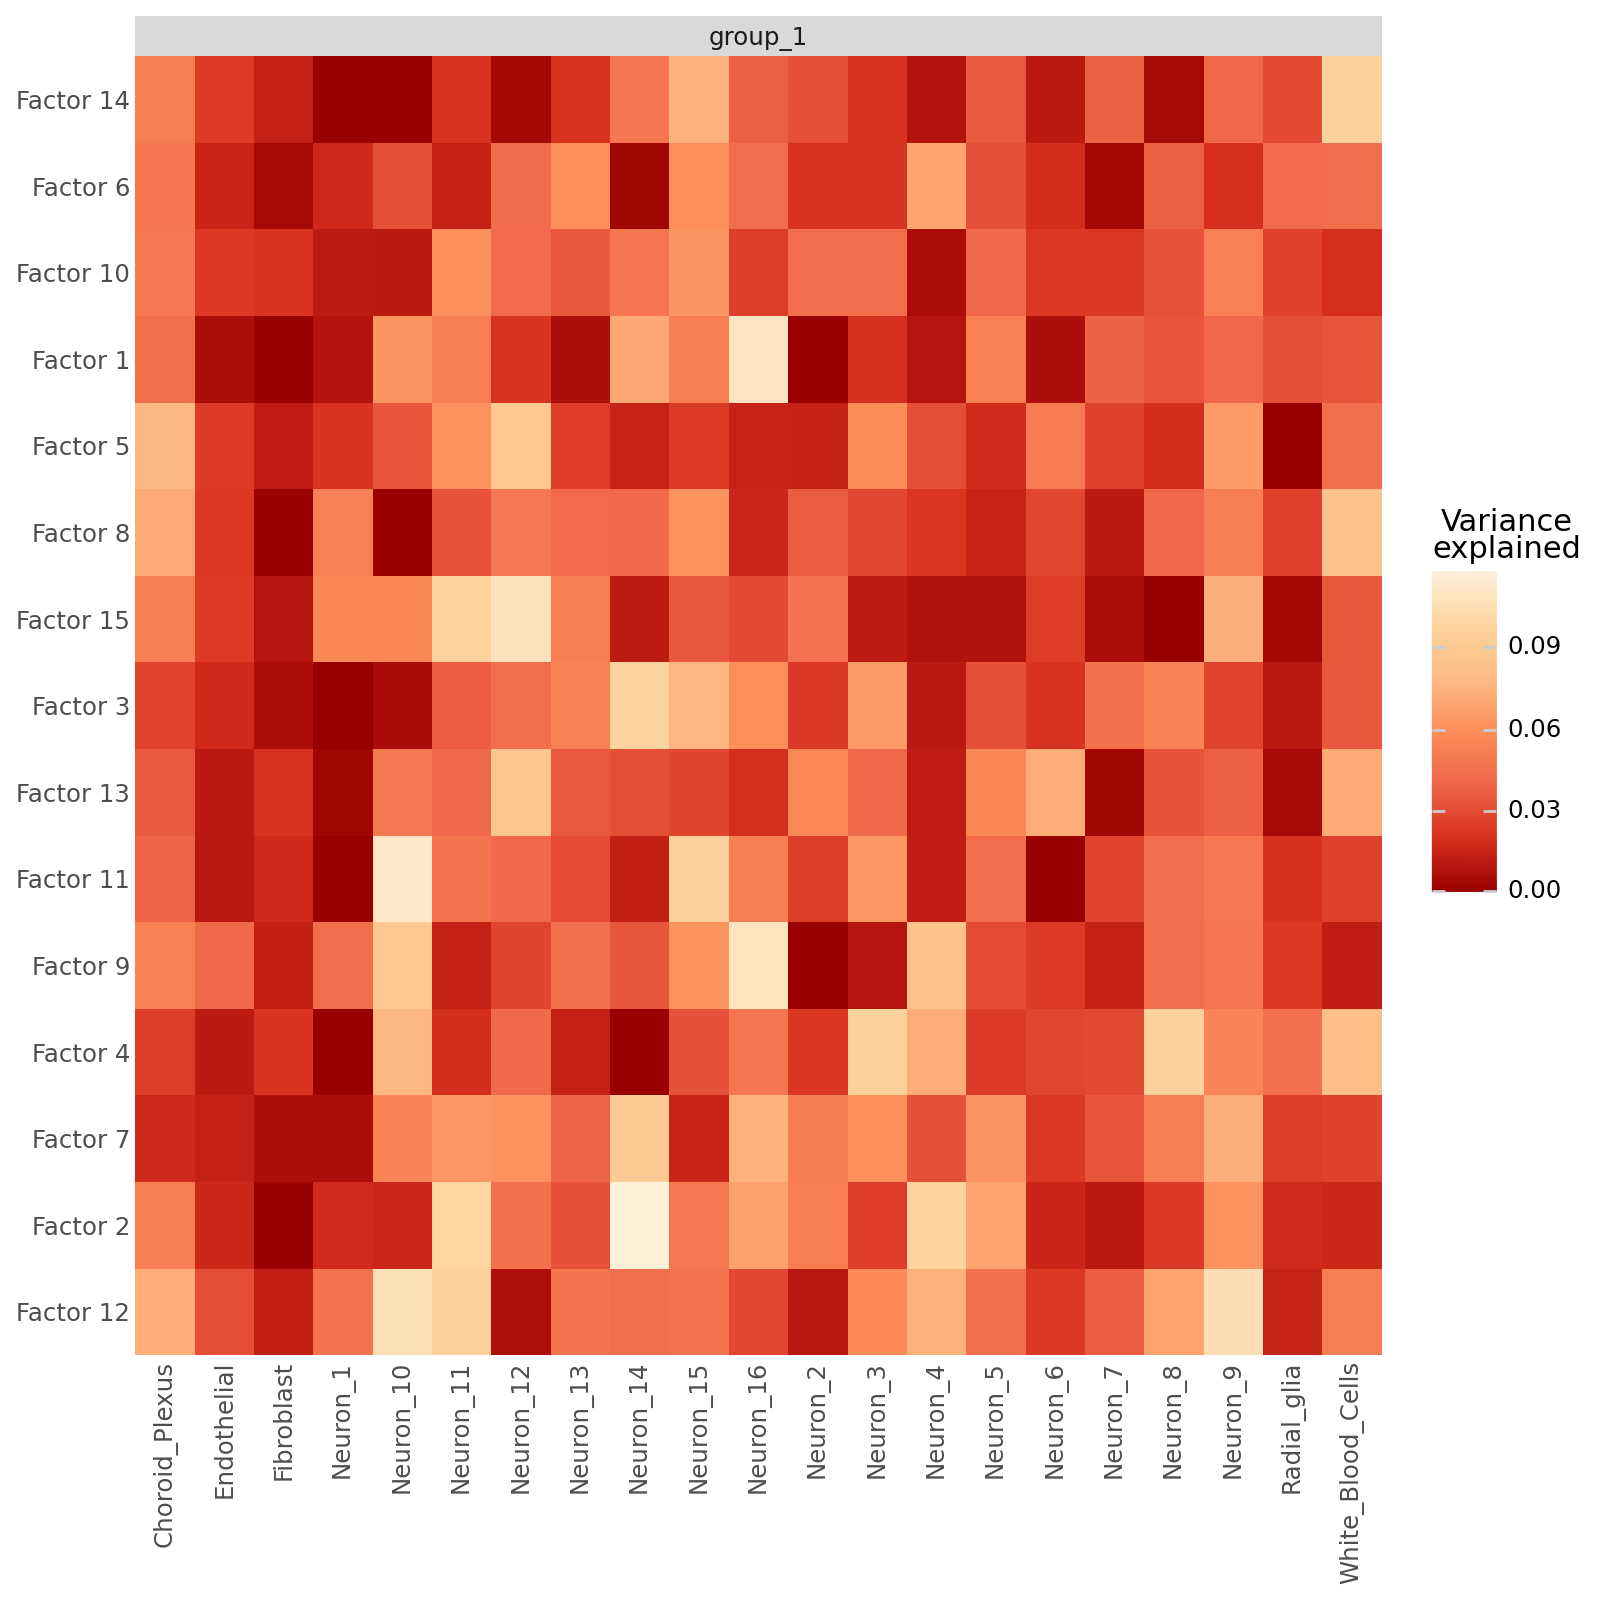

In [12]:
mfl.pl.variance_explained(model, figsize= (8,8))

## 2. Average R2

In [13]:
print(model.get_r2(total=True))

                    group_1
Neuron_3           0.519192
Neuron_8           0.532948
Neuron_4           0.463747
Neuron_12          0.564940
Neuron_9           0.597153
Neuron_14          0.566845
Neuron_6           0.372268
Neuron_10          0.551042
Neuron_11          0.579682
Neuron_5           0.482428
Neuron_13          0.499222
Choroid_Plexus     0.625991
Neuron_16          0.578534
Neuron_2           0.386809
Radial_glia        0.327279
Neuron_1           0.311986
Endothelial        0.322043
Neuron_15          0.618324
Fibroblast         0.301684
White_Blood_Cells  0.694975
Neuron_7           0.330676


In [14]:
r2 = model.get_r2(total=True)
r2["group_1"].mean()

np.float64(0.48703650751370003)

## 3.Weights dist

In [15]:
weights_dict= model.get_weights()

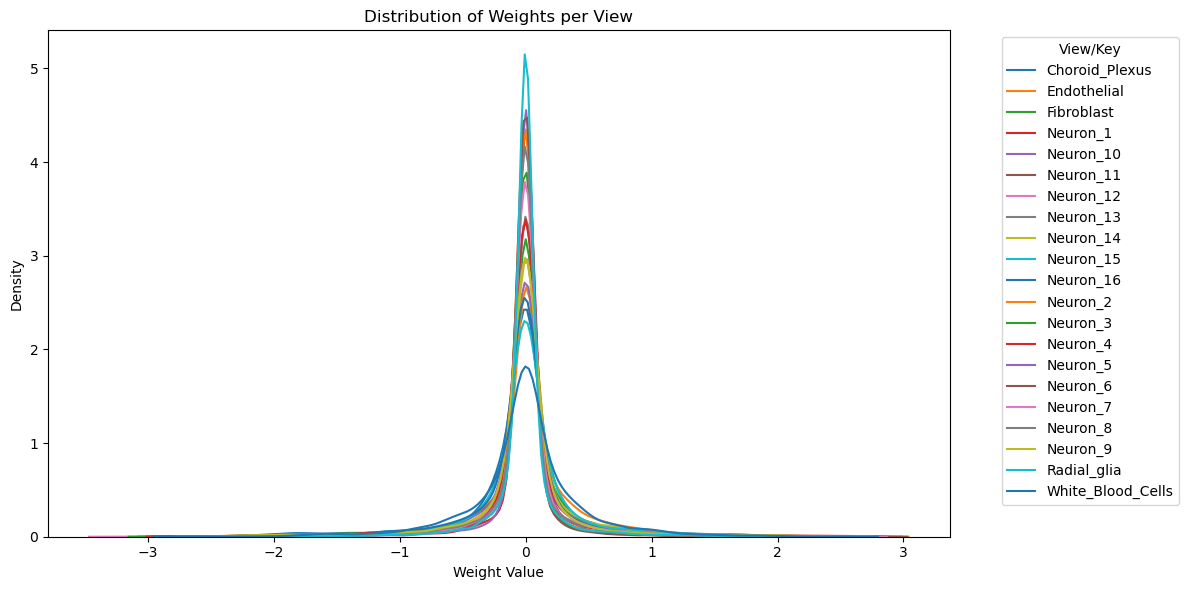

In [16]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
#mfl.pl.all_weights(model_gp, views=['fib2'], figsize=(8,8), show_featurenames=True)
#mfl.pl.weights(model, n_features=10, views=["fib2"], factors=1, pointsize=2, figsize=(8,8))
#mfl.pl.top_weights(model, n_features=15, views="fib2", factors=1)

## 4. Heatmap (view x LR)

In [17]:
from string import ascii_uppercase
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [18]:
weights = model.get_weights()

In [19]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 12

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


# DR using factors values

In [20]:
factors = model.get_factors()
factors = factors["group_1"]

In [21]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
AAACGAAAGAATTCAG-1,-0.002684,-0.898036,-0.647425,0.168647,0.114533,0.213136,0.735919,-0.140947,-0.936021,1.645055,0.119643,-0.033431,-0.335680,-0.031165,0.665656
AAACGAACAGAGAGGG-1,0.035920,-0.174894,-0.007090,-0.063647,0.033035,0.012514,0.102986,0.036647,0.164098,0.051782,-0.020599,0.081392,0.018427,0.124129,0.284937
AAAGGATGTGTTGCCG-1,-0.375055,0.043572,0.074227,0.490495,0.242858,-0.567911,0.020267,-0.047600,-0.340825,0.674416,-0.414014,-0.032894,0.292623,0.144493,-0.484368
AAAGGTAGTCAGACGA-1,0.109092,-0.384400,-0.139257,-0.047784,0.083426,0.207713,0.268217,0.047002,-0.040492,-0.055940,-0.078270,0.220302,-0.017974,0.091555,-0.034339
AAAGGTATCAGACTGT-1,0.017862,0.037987,-0.114196,-0.183489,0.215931,0.067679,0.124977,0.197852,-0.030780,-0.071682,0.096105,0.090792,0.349442,0.016013,-0.110512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGATAGCCATGCC-1,-0.329108,-0.612235,-0.265447,0.113727,1.443840,-1.419888,-0.933176,-1.154903,-0.524616,2.081204,-0.707932,-0.871034,-0.570861,0.148239,-0.405694
TTTGGAGAGCCAACCC-1,-2.324686,-1.292233,0.805113,-2.741164,1.556686,0.532586,-2.376444,-1.033868,-1.429620,-0.620291,-0.140641,0.929293,-1.037286,0.789060,-1.758828
GCAGCTGAGGCTGTAG-1,1.894205,-1.146114,2.592534,-2.190716,1.888848,2.310140,-2.595744,-2.027593,2.579801,0.116805,-2.999192,-2.366143,-1.855394,-1.815331,1.367100
CTGTGAAAGTAGAATC-1,-0.481573,-1.013497,-0.006909,-0.496739,0.779463,-3.024675,1.330594,-3.212774,0.278994,0.026710,0.734926,-0.621469,3.110161,-2.502807,0.674871


### Load lrdata

In [23]:
data_path = Path("/g/stegle/aalsayah/repos/data/slidatag/slidetags/lrdata")
lrdata = sc.read_h5ad(data_path/ "SCP2170.h5ad")

In [25]:
lv1 = lrdata.obs["cell_type"]

In [26]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(4597,)

## UMAP

In [27]:
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import hdbscan

In [28]:
# --- Standardize ---
scaler = StandardScaler()
X = scaler.fit_transform(factors)

### higher-D

In [29]:
# --- UMAP for clustering (higher-D) ---
umap_clusters = umap.UMAP(
    n_components=10,
    n_neighbors=50,         
    min_dist=0.2,           
    metric="euclidean",      
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [30]:
# --- HDBSCAN: start conservative ---
n = X.shape[0]
mcs = max(30, int(np.sqrt(n)))  
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=None,               
    cluster_selection_method="eom",  
    cluster_selection_epsilon=0.05  
).fit(umap_clusters)

labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_rate = (labels == -1).mean()
print(f"clusters={n_clusters}, noise={noise_rate:.2%}")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


clusters=11, noise=58.99%


#### 2D UMAP

In [31]:
# --- 2D UMAP for visualization only ---
umap2 = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.2,
    metric="euclidean",
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [32]:
df_umap = pd.DataFrame(umap2, columns=['UMAP1','UMAP2'], index=factors.index)
df_umap['Cluster'] = labels
df_umap['Conf'] = clusterer.probabilities_  # how confident each assignment is

#### Plot UMAP

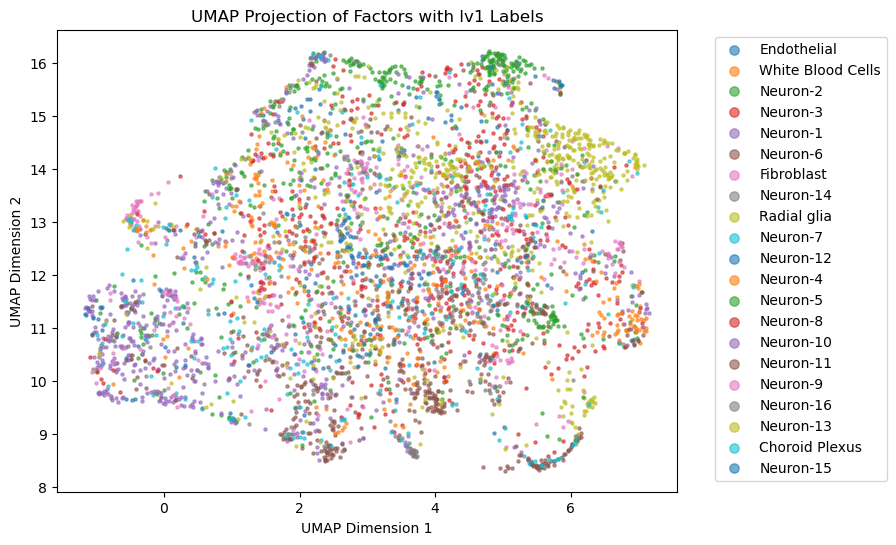

In [33]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

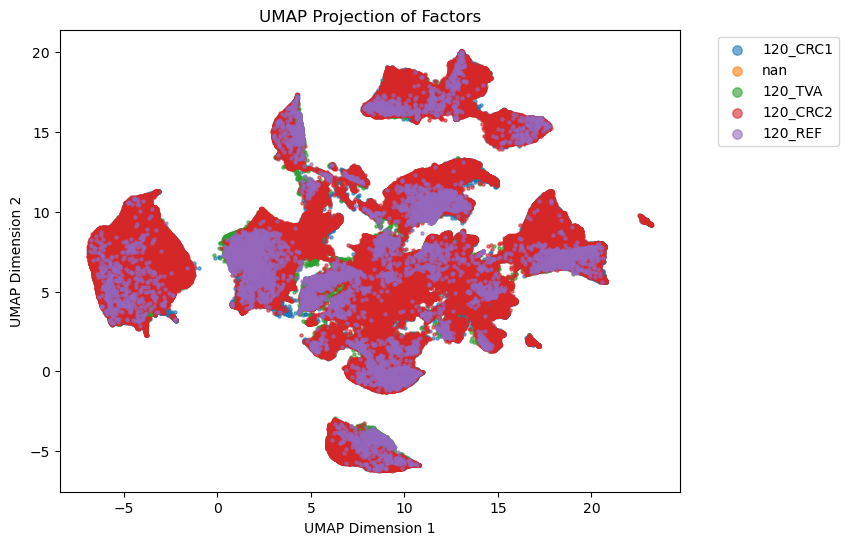

In [28]:
df_umap['Label'] = typ.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

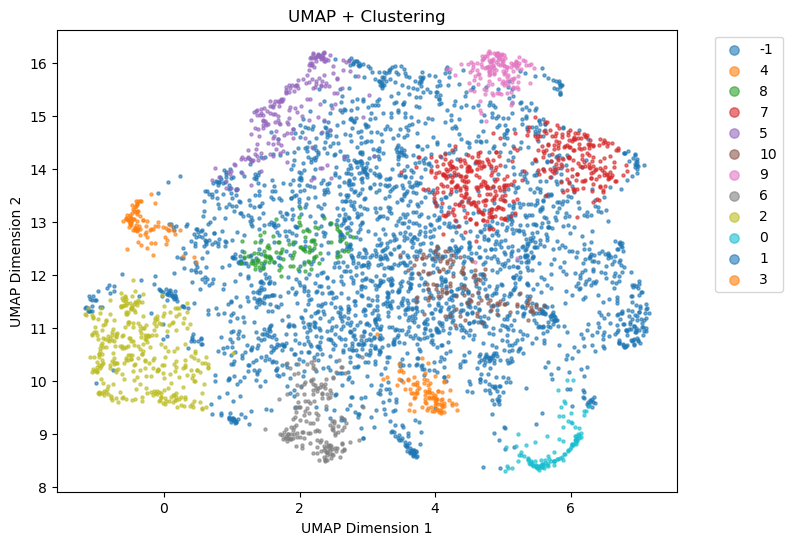

In [51]:
#Plot clusters

plt.figure(figsize=(8,6))
for label in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Regression Model

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [35]:
#get variables 
factors = model.get_factors() 
F = factors["group_1"]

#Get dependent var, change typ to any metadata column you wish to predict if factor values can predict
cell_names = F.index
cell_types = lrdata.obs["cell_type"]

#Sort both
cell_types = cell_types.sort_index()
F=  F.sort_index()

#Filter out any datapoint in response var that is not in features
filtered_cell_types = cell_types.loc[cell_types.index.isin(cell_names)]

### Create X and Y objects

In [36]:
F

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
AAACCCAAGACAGCTG-1,-0.155514,-0.272747,0.160073,-0.048013,-0.224313,0.649337,-0.261006,-0.514884,0.108232,0.143663,-0.274782,-0.500512,0.332997,-0.140723,0.140497
AAACCCACACACGGAA-1,0.051002,-0.001289,0.084084,0.127282,-0.051328,-0.185453,-0.106829,0.021989,0.040724,0.045536,0.155107,0.072178,0.216133,0.045022,0.011292
AAACCCACAGGTTCCG-1,-0.057175,-0.120734,0.799992,0.947793,-0.805609,0.693201,0.589115,0.377845,0.727355,-0.383317,0.454324,0.234220,-0.468584,-0.982249,0.746123
AAACGAAAGAATTCAG-1,-0.002684,-0.898036,-0.647425,0.168647,0.114533,0.213136,0.735919,-0.140947,-0.936021,1.645055,0.119643,-0.033431,-0.335680,-0.031165,0.665656
AAACGAAAGCTATCTG-1,0.120010,-0.017297,0.153639,0.019483,-0.097556,0.026877,-0.133587,0.071712,0.008174,-0.029996,-0.260124,-0.214287,-0.024836,0.130684,-0.162151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTCAAAGAT-1,0.012860,0.161802,0.015701,0.135418,0.095857,0.104013,-0.029511,0.004502,-0.138694,-0.146840,-0.014361,0.055282,-0.008856,-0.114705,0.079956
TTTGGTTGTTCCAGGC-1,-0.204102,-0.388892,0.111249,0.439302,0.170072,0.057294,0.606447,-0.243193,-0.186125,-0.084756,-0.184611,-0.064487,0.037037,-0.599344,-0.289070
TTTGTTGCAAGGTTGG-1,-0.162130,-0.022034,-0.538667,-0.387797,-0.043787,-0.351843,-0.378381,0.031417,-0.348617,0.023703,0.237894,-0.311721,-0.183648,-0.113748,-0.073213
TTTGTTGCAGAGATGC-1,-0.469264,0.265553,-0.309728,-0.408521,0.201212,-0.043359,-0.200034,0.187220,-0.004370,0.031412,0.274093,-0.088317,0.424658,-0.056629,-0.497530


In [37]:
filtered_cell_types

AAACCCAAGACAGCTG-1    Radial glia
AAACCCACACACGGAA-1    Radial glia
AAACCCACAGGTTCCG-1    Radial glia
AAACGAAAGAATTCAG-1    Endothelial
AAACGAAAGCTATCTG-1       Neuron-5
                         ...     
TTTGGTTGTCAAAGAT-1       Neuron-8
TTTGGTTGTTCCAGGC-1       Neuron-3
TTTGTTGCAAGGTTGG-1       Neuron-6
TTTGTTGCAGAGATGC-1      Neuron-12
TTTGTTGGTGCGGCTT-1       Neuron-1
Name: cell_type, Length: 4597, dtype: category
Categories (21, object): ['Choroid Plexus', 'Endothelial', 'Fibroblast', 'Neuron-1', ..., 'Neuron-15', 'Neuron-16', 'Radial glia', 'White Blood Cells']

In [38]:
X = F.values
y = filtered_cell_types.values  # labels

In [39]:
#Drop NaN labels
mask = ~pd.isna(y)
X = X[mask]
y = y[mask]

In [40]:
print(X.shape, y.shape)

(4597, 15) (4597,)


In [41]:
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Median:", np.median(X))
print("Std dev:", np.std(X))

Min: -3.480333
Max: 3.4154556
Mean: -0.00872714
Median: 0.0012806306
Std dev: 0.48513013


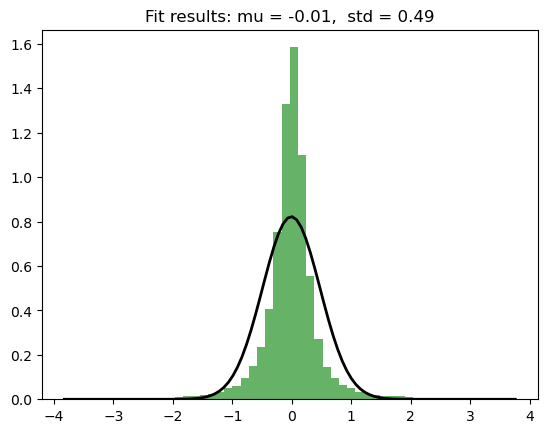

In [42]:
from scipy.stats import norm

data = X.flatten()

# histogram
plt.hist(data, bins=50, density=True, alpha=0.6, color='g')

# fit a normal
mu, std = norm.fit(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title(f"Fit results: mu = {mu:.2f},  std = {std:.2f}")
plt.show()


### Train multinomial logistic regression

In [43]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [44]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [45]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

### Evaluate the model

In [46]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.3094202898550725

Classification Report:
                    precision    recall  f1-score   support

   Choroid Plexus       0.00      0.00      0.00        15
      Endothelial       0.17      0.35      0.23        23
       Fibroblast       0.46      0.35      0.40        66
         Neuron-1       0.48      0.45      0.46       179
        Neuron-10       0.29      0.41      0.34        44
        Neuron-11       0.33      0.30      0.32        43
        Neuron-12       0.17      0.23      0.20        43
        Neuron-13       0.26      0.33      0.29        30
        Neuron-14       0.10      0.19      0.13        27
        Neuron-15       0.20      0.50      0.28        18
        Neuron-16       0.11      0.22      0.15        18
         Neuron-2       0.42      0.28      0.34       117
         Neuron-3       0.23      0.13      0.17       112
         Neuron-4       0.31      0.24      0.27        87
         Neuron-5       0.44      0.44      0.44        81
 

### AUC

In [47]:
from sklearn.metrics import roc_auc_score, roc_curve

#### 1. If threr are 2 classes only (REF vs. CRC)

AUC: 0.6078538535729829


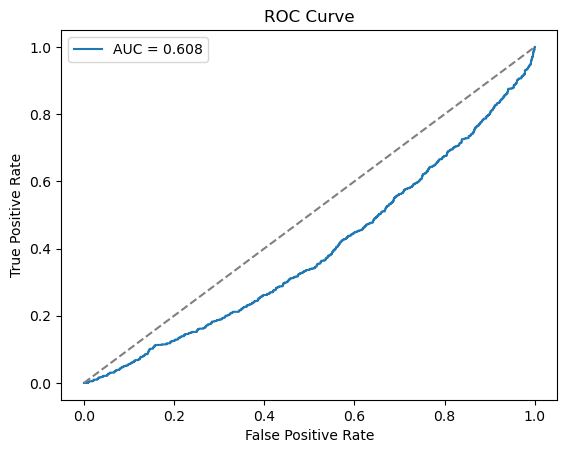

In [87]:
# Get predicted probabilities for the positive class (assume label "232_REF" is positive)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="222_REF")
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### 2. If classes are more than 2:

In [49]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.7386
Multiclass ROC AUC (OvR, weighted): 0.7589


# Map clusters to spatial 

In [50]:
df_umap

,UMAP1,UMAP2,Cluster,Conf,Label
AAACGAAAGAATTCAG-1,3.168307,14.184641,-1,0.000000,Endothelial
AAACGAACAGAGAGGG-1,-0.157538,12.371339,4,1.000000,White Blood Cells
AAAGGATGTGTTGCCG-1,4.286737,12.457191,-1,0.000000,Neuron-2
AAAGGTAGTCAGACGA-1,2.454076,14.737033,-1,0.000000,Neuron-3
AAAGGTATCAGACTGT-1,2.360119,13.070787,8,0.983509,Neuron-3
...,...,...,...,...,...
TTTCGATAGCCATGCC-1,4.890424,10.639476,-1,0.000000,Fibroblast
TTTGGAGAGCCAACCC-1,3.580101,14.633871,-1,0.000000,Neuron-3
GCAGCTGAGGCTGTAG-1,1.445484,11.482833,-1,0.000000,Fibroblast
CTGTGAAAGTAGAATC-1,5.412518,12.429320,-1,0.000000,Radial glia


In [46]:
clusters = df_umap['Cluster'].reindex(lrdata.obs_names)
print(f"Missing cluster labels: {clusters.isna().sum()}")

Missing cluster labels: 285867


In [47]:
lrdata.obs['Cluster'] = clusters.astype('category')

/scratch/jobs/37429356/ipykernel_2919112/1180120996.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


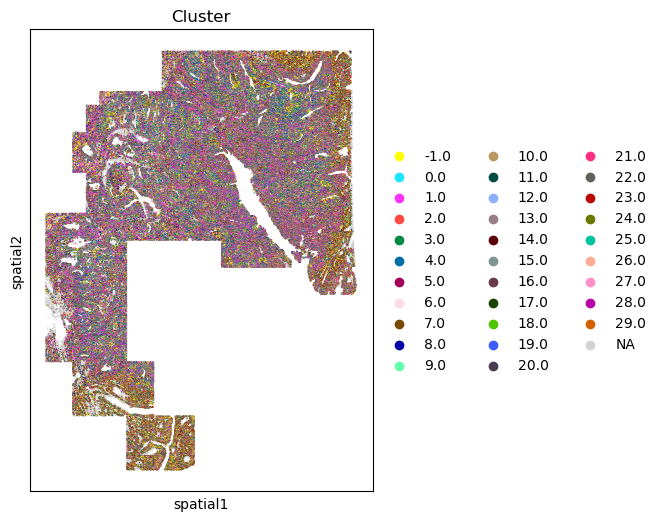

In [48]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    lrdata,
    color='Cluster',
    spot_size=40,
    ax=axes
)
plt.tight_layout()